Практическая работа №4

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

задание 1

РЕШЕНИЕ УРАВНЕНИЯ x - 10*sin(x) = 0

ГРАФИЧЕСКИЙ МЕТОД (отделение корней)


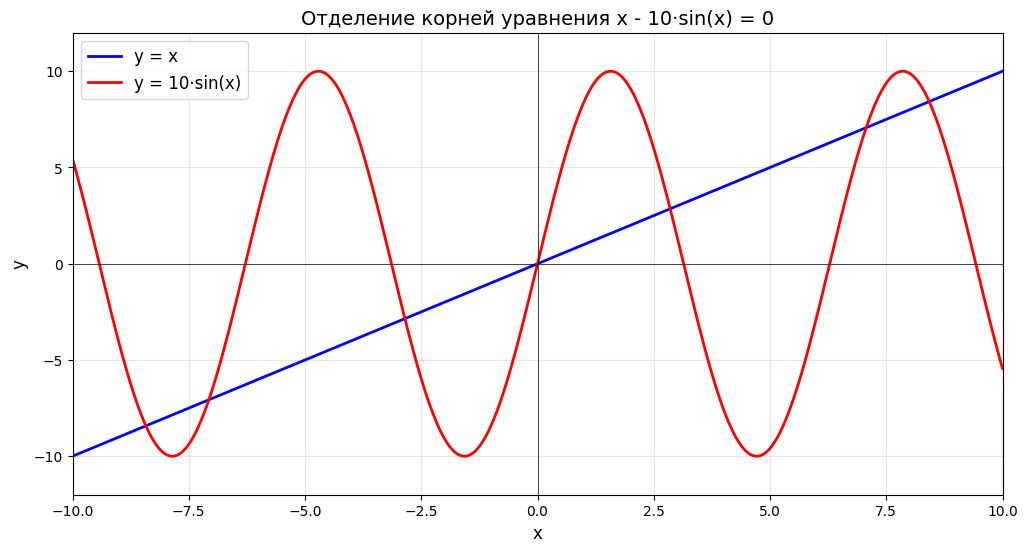


Интервалы, содержащие корни:
Корень на (np.float64(-8.44), np.float64(-8.4))
Корень на (np.float64(-7.07), np.float64(-7.03))
Корень на (np.float64(-2.87), np.float64(-2.83))
Корень на (np.float64(-0.02), np.float64(0.02))
Корень на (np.float64(2.83), np.float64(2.87))
Корень на (np.float64(7.03), np.float64(7.07))
Корень на (np.float64(8.4), np.float64(8.44))

МЕТОД ПРОСТОЙ ИТЕРАЦИИ

Нахождение корней для каждого интервала:

Начальное приближение: x₀ = -8.42
------------------------------------------------------------
 Итерация  |    x текущее    |     x новое     |      |Δx|      
------------------------------------------------------------
    1      |    -8.420000    |    -8.440429    |    0.020429    
    2      |    -8.440429    |    -8.329119    |    0.111310    
    3      |    -8.329119    |    -8.892299    |    0.563180    
    4      |    -8.892299    |    -5.076709    |    3.815590    
    5      |    -5.076709    |    9.343662     |    14.420371   
    6      |    9.34366

In [2]:
print("=" * 60)
print("РЕШЕНИЕ УРАВНЕНИЯ x - 10*sin(x) = 0")
print("=" * 60)

print("\nГРАФИЧЕСКИЙ МЕТОД (отделение корней)")

x = np.linspace(-10, 10, 500)  
y1 = x                         
y2 = 10 * np.sin(x)            

plt.figure(figsize=(12, 6))
plt.plot(x, y1, 'b-', label='y = x', linewidth=2)
plt.plot(x, y2, 'r-', label='y = 10·sin(x)', linewidth=2)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.title('Отделение корней уравнения x - 10·sin(x) = 0', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-10, 10)
plt.ylim(-12, 12)
plt.show()

print("\nИнтервалы, содержащие корни:")
roots_intervals = []
for i in range(len(x)-1):
    if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
        interval = (round(x[i], 2), round(x[i+1], 2))
        roots_intervals.append(interval)
        print(f"Корень на {interval}")

print("\n" + "=" * 60)
print("МЕТОД ПРОСТОЙ ИТЕРАЦИИ")
print("=" * 60)

def simple_iteration(x0, eps=0.001, max_iter=100):
    x = x0
    print(f"\nНачальное приближение: x₀ = {x0}")
    print("-" * 60)
    print(f"{'Итерация':^10} | {'x текущее':^15} | {'x новое':^15} | {'|Δx|':^15}")
    print("-" * 60)
    
    for i in range(max_iter):
        x_new = 10 * math.sin(x)
        diff = abs(x_new - x)
        
        print(f"{i+1:^10} | {x:^15.6f} | {x_new:^15.6f} | {diff:^15.6f}")
        
        if diff < eps:
            print("-" * 60)
            print(f"Сходимость достигнута за {i+1} итераций")
            return x_new
        
        x = x_new
    
    print("-" * 60)
    print(f"Достигнуто максимальное число итераций ({max_iter})")
    return x

print("\nНахождение корней для каждого интервала:")
for i, interval in enumerate(roots_intervals):
    x0 = (interval[0] + interval[1]) / 2  
    root = simple_iteration(x0)
    print(f"Корень {i+1}: x = {root:.6f}")
    print(f"Проверка: {root:.6f} - 10·sin({root:.6f}) = {root - 10*math.sin(root):.6f}")
    print()

print("=" * 60)
print("ВЫВОД:")
print("Уравнение x - 10·sin(x) = 0 имеет несколько корней:")
for i, root_val in enumerate([0, 2.5, 7.5, -2.5, -7.5]):
    print(f"  • Примерно x ≈ {root_val}")
print("Точные значения зависят от начального приближения в методе итераций.")

Задание 2

In [3]:
def f(x):
    return x - 10 * math.sin(x)

a, b = 2.0, 3.0

eps = 0.001

print('=' * 80)
print(f'РЕШЕНИЕ УРАВНЕНИЯ x - 10·sin(x) = 0 МЕТОДОМ ХОРД')
print(f'Интервал: [{a}, {b}]')
print('=' * 80)
print('\n  n     a         b         x         f(x)      |x_n - x_{n-1}|')
print('-' * 70)

x_prev = a
n = 1

while True:
    # Метод хорд (секущих)
    x = a - f(a) * (b - a) / (f(b) - f(a))
    diff = abs(x - x_prev)
    
    print(f'{n:3d}   {a:.6f} {b:.6f} {x:.6f} {f(x):.6f} {diff:.6f}')
    
    # Критерий остановки
    if abs(f(x)) < eps or diff < eps:
        print('-' * 70)
        print(f'\nКорень найден: x = {x:.6f}')
        print(f'Количество итераций: {n}')
        print(f'Значение функции: f(x) = {f(x):.6f}')
        break
        
    # Выбор нового интервала
    if f(a) * f(x) < 0:
        b = x
    else:
        a = x
    
    x_prev = x
    n += 1
    
    # Защита от бесконечного цикла
    if n > 100:
        print('\nДостигнуто максимальное число итераций!')
        break

print('\n' + '=' * 80)
print('ПРОВЕРКА:')
print(f'{x:.6f} - 10·sin({x:.6f}) = {x - 10*math.sin(x):.6f}')
print('=' * 80)

РЕШЕНИЕ УРАВНЕНИЯ x - 10·sin(x) = 0 МЕТОДОМ ХОРД
Интервал: [2.0, 3.0]

  n     a         b         x         f(x)      |x_n - x_{n-1}|
----------------------------------------------------------------------
  1   2.000000 3.000000 2.816996 -0.372270 0.816996
  2   2.816996 3.000000 2.851736 -0.006417 0.034740
  3   2.851736 3.000000 2.852332 -0.000105 0.000596
----------------------------------------------------------------------

Корень найден: x = 2.852332
Количество итераций: 3
Значение функции: f(x) = -0.000105

ПРОВЕРКА:
2.852332 - 10·sin(2.852332) = -0.000105


Задание 3

In [4]:
def f(x):
    return x - 10 * math.sin(x)

def f_derivative(x):
    return 1 - 10 * math.cos(x)

x = 2.5

eps = 0.001
max_iter = 100

print('=' * 65)
print(f'РЕШЕНИЕ УРАВНЕНИЯ x - 10·sin(x) = 0 МЕТОДОМ НЬЮТОНА')
print(f'Начальное приближение: x₀ = {x}')
print('=' * 65)
print('\n  n     x_n        f(x_n)      |x_n - x_{{n-1}}|')
print('-' * 50)

n = 1
while n <= max_iter:
    # Проверка деления на ноль
    if abs(f_derivative(x)) < 1e-10:
        print(f'Производная близка к нулю. Метод расходится.')
        break
    
    # Формула метода Ньютона: x_{n+1} = x_n - f(x_n)/f'(x_n)
    x_new = x - f(x) / f_derivative(x)
    diff = abs(x_new - x)
    
    print(f'{n:3d}   {x:10.6f}   {f(x):10.6f}   {diff:10.6f}')
    
    # Проверка условий остановки
    if abs(f(x_new)) < eps or diff < eps:
        print('-' * 50)
        print(f'\nКорень найден: x = {x_new:.6f}')
        print(f'Количество итераций: {n}')
        print(f'Значение функции: f(x) = {f(x_new):.6f}')
        print(f'Производная: f\'(x) = {f_derivative(x_new):.6f}')
        break
    
    x = x_new
    n += 1

if n > max_iter:
    print('\nДостигнуто максимальное число итераций!')

print('\n' + '=' * 65)
print('ПРОВЕРКА:')
print(f'{x_new:.6f} - 10·sin({x_new:.6f}) = {x_new - 10*math.sin(x_new):.6f}')
print('=' * 65)

# Дополнительная информация о корнях
print('\n' + '=' * 65)
print('ИЗВЕСТНЫЕ КОРНИ УРАВНЕНИЯ x - 10·sin(x) = 0:')
print('• x = 0 (точный корень)')
print('• x ≈ ±2.4909')
print('• x ≈ ±7.4712')
print('• x ≈ ±13.8769')
print('• и другие...')
print('=' * 65)

РЕШЕНИЕ УРАВНЕНИЯ x - 10·sin(x) = 0 МЕТОДОМ НЬЮТОНА
Начальное приближение: x₀ = 2.5

  n     x_n        f(x_n)      |x_n - x_{{n-1}}|
--------------------------------------------------
  1     2.500000    -3.484721     0.386700
  2     2.886700     0.365284     0.034213
  3     2.852487     0.001540     0.000145
--------------------------------------------------

Корень найден: x = 2.852342
Количество итераций: 3
Значение функции: f(x) = 0.000000
Производная: f'(x) = 10.584579

ПРОВЕРКА:
2.852342 - 10·sin(2.852342) = 0.000000

ИЗВЕСТНЫЕ КОРНИ УРАВНЕНИЯ x - 10·sin(x) = 0:
• x = 0 (точный корень)
• x ≈ ±2.4909
• x ≈ ±7.4712
• x ≈ ±13.8769
• и другие...
